In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split
)

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.preprocessing import (
    LabelEncoder
)

In [6]:
feature_df = pd.read_csv("feature_usage_dataset.csv")

funnel_df = pd.read_csv("funnel_events_dataset.csv")

nlp_df = pd.read_csv("reviews_complaints_dataset.csv")

# Create Aggregated Funnel Metrics

In [7]:
funnel_metrics = (

    funnel_df.groupby("feature_name")
    .agg({

        "rage_clicks": "mean",

        "retries": "mean",

        "dropoff_flag": "mean",

        "error_flag": "mean",

        "stage_completed": "mean"

    })

    .reset_index()

)

print(funnel_metrics.head())

         feature_name  rage_clicks   retries  dropoff_flag  error_flag  \
0  AI Recommendations     0.114537  0.060846      0.183930    0.041096   
1           Downloads     0.116692  0.059970      0.116972    0.039616   
2  Mini Preview Clips     0.114011  0.060706      0.288170    0.037558   
3         Watch Party     0.141914  0.083902      0.371107    0.121351   
4           Watchlist     0.116771  0.058083      0.136630    0.038547   

   stage_completed  
0         0.751953  
1         0.842712  
2         0.674883  
3         0.626567  
4         0.803915  


# Create Aggregated NLP Metrics

In [8]:
nlp_metrics = (

    nlp_df.groupby("feature_name")
    .agg({

        "rating": "mean",

        "support_ticket_flag": "mean"

    })

    .reset_index()

)

print(nlp_metrics.head())

         feature_name    rating  support_ticket_flag
0  AI Recommendations  2.961219             0.149091
1           Downloads  4.175416             0.042500
2  Mini Preview Clips  2.455782             0.250833
3         Watch Party  2.235696             0.276667
4           Watchlist  3.571637             0.085714


# Create Feature-Level Metrics

In [9]:
feature_metrics = (

    feature_df.groupby("feature_name")
    .agg({

        "engagement_score": "mean",

        "retention_30d": "mean",

        "churn_flag": "mean",

        "reused_feature": "mean",

        "watch_time_minutes": "mean"

    })

    .reset_index()

)

print(feature_metrics.head())

         feature_name  engagement_score  retention_30d  churn_flag  \
0  AI Recommendations          0.347817       0.278908    0.251211   
1           Downloads          0.324586       0.573345    0.099244   
2  Mini Preview Clips          0.326829       0.179694    0.302176   
3         Watch Party          0.300755       0.067513    0.451431   
4           Watchlist          0.300679       0.490529    0.151984   

   reused_feature  watch_time_minutes  
0        0.304587           13.841124  
1        0.750214           13.816273  
2        0.300295           13.883909  
3        0.294035           13.591216  
4        0.301376           13.912453  


In [10]:
master_df = pd.merge(

    feature_metrics,

    funnel_metrics,

    on="feature_name"

)

master_df = pd.merge(

    master_df,

    nlp_metrics,

    on="feature_name"

)

print(master_df.head())

         feature_name  engagement_score  retention_30d  churn_flag  \
0  AI Recommendations          0.347817       0.278908    0.251211   
1           Downloads          0.324586       0.573345    0.099244   
2  Mini Preview Clips          0.326829       0.179694    0.302176   
3         Watch Party          0.300755       0.067513    0.451431   
4           Watchlist          0.300679       0.490529    0.151984   

   reused_feature  watch_time_minutes  rage_clicks   retries  dropoff_flag  \
0        0.304587           13.841124     0.114537  0.060846      0.183930   
1        0.750214           13.816273     0.116692  0.059970      0.116972   
2        0.300295           13.883909     0.114011  0.060706      0.288170   
3        0.294035           13.591216     0.141914  0.083902      0.371107   
4        0.301376           13.912453     0.116771  0.058083      0.136630   

   error_flag  stage_completed    rating  support_ticket_flag  
0    0.041096         0.751953  2.961219      

# Create Target Variable

In [11]:
health_map = {

    "Downloads": "Healthy",

    "AI Recommendations": "Healthy",

    "Watchlist": "At Risk",

    "Mini Preview Clips": "At Risk",

    "Watch Party": "Dead"
}

master_df["feature_health"] = (

    master_df["feature_name"]
    .map(health_map)

)

print(master_df)

         feature_name  engagement_score  retention_30d  churn_flag  \
0  AI Recommendations          0.347817       0.278908    0.251211   
1           Downloads          0.324586       0.573345    0.099244   
2  Mini Preview Clips          0.326829       0.179694    0.302176   
3         Watch Party          0.300755       0.067513    0.451431   
4           Watchlist          0.300679       0.490529    0.151984   

   reused_feature  watch_time_minutes  rage_clicks   retries  dropoff_flag  \
0        0.304587           13.841124     0.114537  0.060846      0.183930   
1        0.750214           13.816273     0.116692  0.059970      0.116972   
2        0.300295           13.883909     0.114011  0.060706      0.288170   
3        0.294035           13.591216     0.141914  0.083902      0.371107   
4        0.301376           13.912453     0.116771  0.058083      0.136630   

   error_flag  stage_completed    rating  support_ticket_flag feature_health  
0    0.041096         0.751953 

# Encode Target

In [12]:
encoder = LabelEncoder()

master_df["target"] = encoder.fit_transform(

    master_df["feature_health"]

)

print(master_df[
    ["feature_name", "target"]
])

         feature_name  target
0  AI Recommendations       2
1           Downloads       2
2  Mini Preview Clips       0
3         Watch Party       1
4           Watchlist       0


In [13]:
X = master_df[

    [

        "engagement_score",

        "retention_30d",

        "churn_flag",

        "reused_feature",

        "watch_time_minutes",

        "rage_clicks",

        "retries",

        "dropoff_flag",

        "error_flag",

        "stage_completed",

        "rating",

        "support_ticket_flag"

    ]

]

y = master_df["target"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [15]:
model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [16]:
predictions = model.predict(
    X_test
)

In [17]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.0


In [18]:
print(

    classification_report(
        y_test,
        predictions
    )

)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

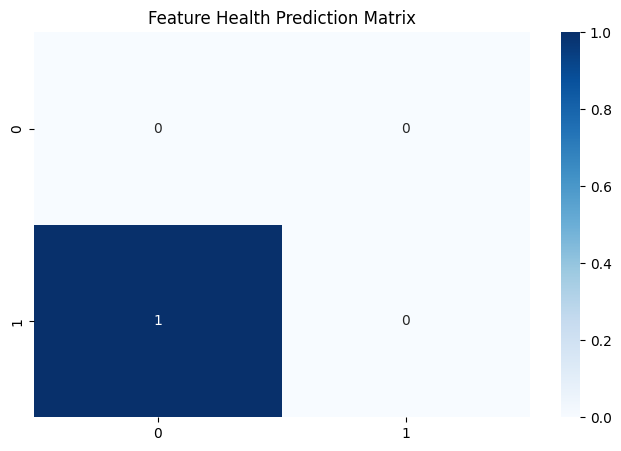

In [19]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(8,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Feature Health Prediction Matrix"
)

plt.show()

# Feature Importance

In [20]:
importance = pd.DataFrame({

    "feature": X.columns,

    "importance": model.feature_importances_

})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance)

                feature  importance
6               retries    0.125362
3        reused_feature    0.106522
8            error_flag    0.104348
4    watch_time_minutes    0.102174
2            churn_flag    0.086957
7          dropoff_flag    0.086232
10               rating    0.071014
11  support_ticket_flag    0.070290
9       stage_completed    0.067391
5           rage_clicks    0.065217
1         retention_30d    0.057971
0      engagement_score    0.056522


/tmp/ipykernel_9258/2206042611.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


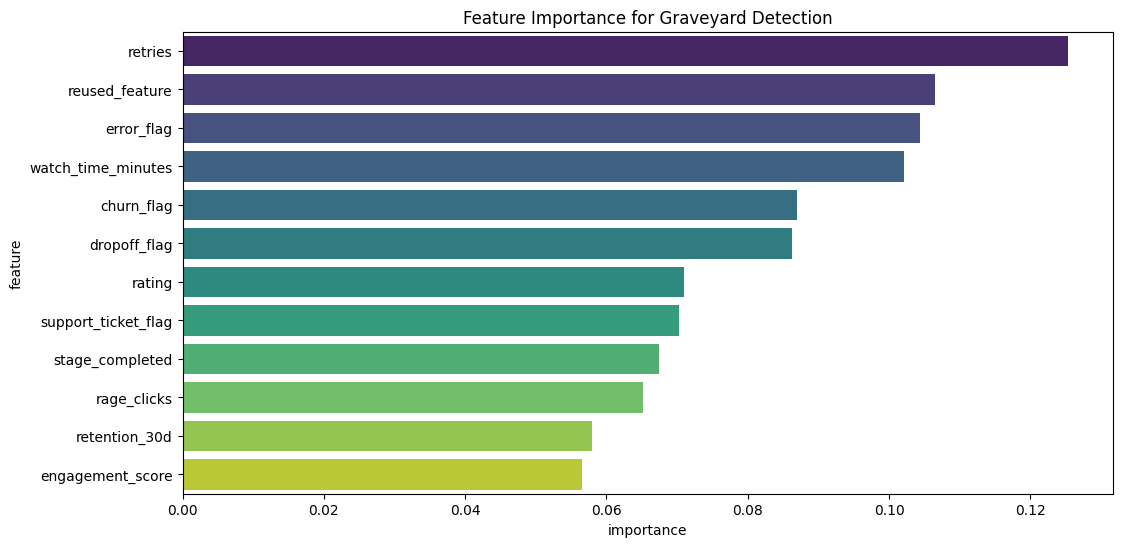

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=importance,
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title(
    "Feature Importance for Graveyard Detection"
)

plt.show()

In [22]:
master_df["predicted_health"] = (

    encoder.inverse_transform(

        model.predict(X)

    )

)

print(

    master_df[

        [

            "feature_name",

            "predicted_health"

        ]

    ]

)

         feature_name predicted_health
0  AI Recommendations          Healthy
1           Downloads          At Risk
2  Mini Preview Clips          At Risk
3         Watch Party             Dead
4           Watchlist          At Risk


In [23]:
print("=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

print("""
The AI system successfully predicts
feature health using:

- engagement metrics
- funnel friction
- churn behavior
- NLP complaint signals

The model identifies:
- healthy features
- at risk features
- dead features

This creates an AI-powered
Feature Graveyard Detection System.
""")

EXECUTIVE SUMMARY

The AI system successfully predicts
feature health using:

- engagement metrics
- funnel friction
- churn behavior
- NLP complaint signals

The model identifies:
- healthy features
- at risk features
- dead features

This creates an AI-powered
Feature Graveyard Detection System.



In [33]:
# =========================================================
# CREATE app.py FILE IN COLAB
# =========================================================

app_code = '''
# =========================================================
# AI POWERED OTT FEATURE GRAVEYARD DETECTOR
# STREAMLIT DASHBOARD
# =========================================================

import streamlit as st
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# =========================================================
# PAGE CONFIG
# =========================================================

st.set_page_config(
    page_title="OTT Feature Graveyard Detector",
    page_icon="🎬",
    layout="wide"
)

# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown(
    """
    <style>

    .stApp {
        background: linear-gradient(
            135deg,
            #0f172a,
            #111827,
            #1e293b,
            #312e81
        );
        color: white;
    }

    h1, h2, h3, h4, h5 {
        color: white !important;
    }

    section[data-testid="stSidebar"] {
        background: linear-gradient(
            180deg,
            #111827,
            #1e1b4b
        );
    }

    .metric-card {
        padding: 20px;
        border-radius: 18px;
        background: linear-gradient(
            135deg,
            #2563eb,
            #7c3aed
        );
        color: white;
        text-align: center;
        box-shadow: 0px 4px 20px rgba(0,0,0,0.4);
    }

    .prediction-box {
        padding: 25px;
        border-radius: 20px;
        background: linear-gradient(
            135deg,
            #059669,
            #14b8a6
        );
        color: white;
        text-align: center;
        font-size: 30px;
        font-weight: bold;
        box-shadow: 0px 4px 20px rgba(0,0,0,0.4);
    }

    </style>
    """,
    unsafe_allow_html=True
)

# =========================================================
# TITLE
# =========================================================

st.title("🎬 AI Powered OTT Feature Graveyard Detector")

st.markdown("""
### Detect unhealthy OTT features using:
- Product Analytics
- Funnel Analytics
- NLP
- Machine Learning
""")

# =========================================================
# LOAD DATASETS
# =========================================================

feature_df = pd.read_csv(
    "feature_usage_dataset.csv"
)

funnel_df = pd.read_csv(
    "funnel_events_dataset.csv"
)

nlp_df = pd.read_csv(
    "reviews_complaints_dataset.csv"
)

# =========================================================
# SIDEBAR
# =========================================================

st.sidebar.title("📊 Dashboard Controls")

selected_feature = st.sidebar.selectbox(
    "Select Feature",
    feature_df["feature_name"].unique()
)

selected_country = st.sidebar.selectbox(
    "Select Country",
    feature_df["country"].unique()
)

selected_device = st.sidebar.selectbox(
    "Select Device",
    feature_df["device_type"].unique()
)

# =========================================================
# FILTER DATA
# =========================================================

filtered_feature_df = feature_df[
    (feature_df["feature_name"] == selected_feature)
    &
    (feature_df["country"] == selected_country)
    &
    (feature_df["device_type"] == selected_device)
]

# =========================================================
# KPI METRICS
# =========================================================

avg_engagement = round(
    filtered_feature_df["engagement_score"].mean(),
    2
)

avg_retention = round(
    filtered_feature_df["retention_30d"].mean(),
    2
)

avg_churn = round(
    filtered_feature_df["churn_flag"].mean(),
    2
)

col1, col2, col3 = st.columns(3)

with col1:

    st.markdown(
        f"""
        <div class='metric-card'>
        <h3>🔥 Engagement</h3>
        <h1>{avg_engagement}</h1>
        </div>
        """,
        unsafe_allow_html=True
    )

with col2:

    st.markdown(
        f"""
        <div class='metric-card'>
        <h3>📈 Retention</h3>
        <h1>{avg_retention}</h1>
        </div>
        """,
        unsafe_allow_html=True
    )

with col3:

    st.markdown(
        f"""
        <div class='metric-card'>
        <h3>⚠️ Churn</h3>
        <h1>{avg_churn}</h1>
        </div>
        """,
        unsafe_allow_html=True
    )

st.markdown("---")

# =========================================================
# FEATURE HEALTH ANALYSIS
# =========================================================

st.header("📊 Feature Health Analysis")

feature_health = (

    feature_df.groupby("feature_name")
    .agg({

        "engagement_score": "mean",

        "retention_30d": "mean",

        "churn_flag": "mean"

    })

    .reset_index()

)

fig1 = px.bar(
    feature_health,
    x="feature_name",
    y="engagement_score",
    color="retention_30d",
    template="plotly_dark",
    title="Feature Engagement vs Retention"
)

st.plotly_chart(
    fig1,
    use_container_width=True
)

# =========================================================
# FUNNEL ANALYSIS
# =========================================================

st.header("🚀 Funnel Analytics")

funnel_conversion = (

    funnel_df.groupby("funnel_stage")[
        "stage_completed"
    ]
    .sum()
    .reset_index()

)

fig2 = go.Figure(

    go.Funnel(

        y=funnel_conversion["funnel_stage"],

        x=funnel_conversion["stage_completed"],

        textinfo="value+percent initial"

    )

)

fig2.update_layout(
    template="plotly_dark",
    title="OTT Funnel Conversion"
)

st.plotly_chart(
    fig2,
    use_container_width=True
)

# =========================================================
# RAGE CLICK ANALYSIS
# =========================================================

st.header("😡 Rage Click Analysis")

rage_analysis = (

    funnel_df.groupby("feature_name")[
        "rage_clicks"
    ]
    .mean()
    .reset_index()

)

fig3 = px.bar(
    rage_analysis,
    x="feature_name",
    y="rage_clicks",
    color="rage_clicks",
    template="plotly_dark",
    title="Average Rage Clicks"
)

st.plotly_chart(
    fig3,
    use_container_width=True
)

# =========================================================
# NLP ANALYSIS
# =========================================================

st.header("🧠 NLP Complaint Intelligence")

sentiment_counts = (

    nlp_df["sentiment"]
    .value_counts()
    .reset_index()

)

sentiment_counts.columns = [
    "sentiment",
    "count"
]

fig4 = px.pie(
    sentiment_counts,
    names="sentiment",
    values="count",
    template="plotly_dark",
    title="Sentiment Distribution"
)

st.plotly_chart(
    fig4,
    use_container_width=True
)

# =========================================================
# BUILD MASTER DATASET
# =========================================================

funnel_metrics = (

    funnel_df.groupby("feature_name")
    .agg({

        "rage_clicks": "mean",

        "retries": "mean",

        "dropoff_flag": "mean",

        "error_flag": "mean",

        "stage_completed": "mean"

    })

    .reset_index()

)

nlp_metrics = (

    nlp_df.groupby("feature_name")
    .agg({

        "rating": "mean",

        "support_ticket_flag": "mean"

    })

    .reset_index()

)

feature_metrics = (

    feature_df.groupby("feature_name")
    .agg({

        "engagement_score": "mean",

        "retention_30d": "mean",

        "churn_flag": "mean",

        "reused_feature": "mean",

        "watch_time_minutes": "mean"

    })

    .reset_index()

)

master_df = pd.merge(
    feature_metrics,
    funnel_metrics,
    on="feature_name"
)

master_df = pd.merge(
    master_df,
    nlp_metrics,
    on="feature_name"
)

# =========================================================
# TARGET LABELS
# =========================================================

health_map = {

    "Downloads": "Healthy",

    "AI Recommendations": "Healthy",

    "Watchlist": "At Risk",

    "Mini Preview Clips": "At Risk",

    "Watch Party": "Dead"
}

master_df["feature_health"] = (

    master_df["feature_name"]
    .map(health_map)

)

# =========================================================
# ENCODE TARGET
# =========================================================

encoder = LabelEncoder()

master_df["target"] = encoder.fit_transform(
    master_df["feature_health"]
)

# =========================================================
# FEATURES & TARGET
# =========================================================

X = master_df[[

    "engagement_score",

    "retention_30d",

    "churn_flag",

    "reused_feature",

    "watch_time_minutes",

    "rage_clicks",

    "retries",

    "dropoff_flag",

    "error_flag",

    "stage_completed",

    "rating",

    "support_ticket_flag"

]]

y = master_df["target"]

# =========================================================
# TRAIN MODEL
# =========================================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

# =========================================================
# PREDICTION ENGINE
# =========================================================

st.header("🤖 AI Graveyard Prediction Engine")

engagement_input = st.slider(
    "Engagement Score",
    0,
    100,
    50
)

retention_input = st.slider(
    "30D Retention",
    0.0,
    1.0,
    0.5
)

churn_input = st.slider(
    "Churn Rate",
    0.0,
    1.0,
    0.3
)

rage_input = st.slider(
    "Rage Clicks",
    0.0,
    10.0,
    3.0
)

rating_input = st.slider(
    "Feature Rating",
    1.0,
    5.0,
    3.5
)

prediction_data = np.array([[

    engagement_input,

    retention_input,

    churn_input,

    0.5,

    40,

    rage_input,

    2,

    0.4,

    0.2,

    0.7,

    rating_input,

    0.3

]])

prediction = model.predict(
    prediction_data
)

prediction_label = encoder.inverse_transform(
    prediction
)[0]

st.markdown(
    f"""
    <div class='prediction-box'>
    Predicted Feature Health:<br><br>
    {prediction_label}
    </div>
    """,
    unsafe_allow_html=True
)

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

st.header("📌 Feature Importance")

importance = pd.DataFrame({

    "feature": X.columns,

    "importance": model.feature_importances_

})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

fig5 = px.bar(
    importance,
    x="importance",
    y="feature",
    orientation="h",
    color="importance",
    template="plotly_dark",
    title="Feature Importance"
)

st.plotly_chart(
    fig5,
    use_container_width=True
)

# =========================================================
# EXECUTIVE INSIGHTS
# =========================================================

st.header("📌 Executive Insights")

st.success(
    """
    Downloads and AI Recommendations
    are the healthiest OTT features.

    Watch Party demonstrates:
    - high churn
    - low retention
    - high rage clicks
    - strong negative sentiment

    Funnel friction and customer complaints
    strongly influence feature death risk.
    """
)

# =========================================================
# FOOTER
# =========================================================

st.markdown("---")

st.markdown(
    """
    ### 🎯 Technologies Used

    - Product Analytics
    - Funnel Analytics
    - NLP
    - Machine Learning
    - Streamlit
    - Random Forest
    """
)
'''

# =========================================================
# WRITE TO app.py
# =========================================================

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py file created successfully!")

app.py file created successfully!


In [32]:
!pip install streamlit -q
!streamlit run /content/app.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.5 MB/s eta 0:00:00
Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
